In [1]:
import zarr
import numpy as np
from zarr.storage import LMDBStore
from sklearn.metrics import accuracy_score

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [2]:
zarr_preds_path = '../outputs/predictions_pcuk.lmdb'
store = LMDBStore(zarr_preds_path, 
                  map_size=int(1e12), readonly=True)
store = zarr.open_group(store, mode="r")

/tmp/ipykernel_54/1292483722.py:2: FutureWarning: The LMDBStore is deprecated and will be removed in a Zarr-Python version 3, see https://github.com/zarr-developers/zarr-python/issues/1274 for more information.
  store = LMDBStore(zarr_preds_path,


In [3]:
zarr_preds_path = '../outputs/predictions_full_augmentation.lmdb'
aug_store = LMDBStore(zarr_preds_path, 
                  map_size=int(1e12), readonly=True)
aug_store = zarr.open_group(aug_store, mode="r")

/tmp/ipykernel_5249/2630368584.py:2: FutureWarning: The LMDBStore is deprecated and will be removed in a Zarr-Python version 3, see https://github.com/zarr-developers/zarr-python/issues/1274 for more information.
  aug_store = LMDBStore(zarr_preds_path,


In [4]:
zarr_preds_path = '../outputs/predictions_noise_augmentation.lmdb'
noise_store = LMDBStore(zarr_preds_path, 
                  map_size=int(1e12), readonly=True)
noise_store = zarr.open_group(noise_store, mode="r")

/tmp/ipykernel_5249/3116561104.py:2: FutureWarning: The LMDBStore is deprecated and will be removed in a Zarr-Python version 3, see https://github.com/zarr-developers/zarr-python/issues/1274 for more information.
  noise_store = LMDBStore(zarr_preds_path,


In [3]:
def load_image_outputs(
    store: zarr.Group,
    trial_id: str,
    image_name: str,
    load_top_k: bool = False,
) -> dict:
    grp = store[f"{trial_id}/{image_name}"]

    result = {
        "argmax_map": grp["argmax_map"][:],
        "bg_prob":    grp["bg_prob"][:],
        "attrs":      dict(grp.attrs),
    }

    if load_top_k:
        result["top_k_classes"] = grp["top_k_classes"][:]
        result["top_k_probs"]   = grp["top_k_probs"][:]

    return result

def compile_results(store: zarr.Group) -> dict:
    trial_list = sorted(store.keys())
    result_dict = {}
    
    for trial_id in trial_list:
        image_names = sorted(store[trial_id].keys())
        for image_name in image_names:
            img_result = load_image_outputs(store, trial_id, image_name)
            samples_per_class = img_result['attrs']['N']
    
            if samples_per_class not in result_dict:
                result_dict[samples_per_class] = {}
    
            if trial_id not in result_dict[samples_per_class]:
                result_dict[samples_per_class][trial_id] = {'gt': [], 'pred': []}
    
            preds = img_result['argmax_map']
            true_idx = img_result['attrs']['true_idx']
            nonzero_preds = preds[preds != 0]
            gt = np.ones(nonzero_preds.shape) * true_idx
    
            result_dict[samples_per_class][trial_id]['gt'].append(gt)
            result_dict[samples_per_class][trial_id]['pred'].append(nonzero_preds)
    
    for samples_per_class in result_dict:
        for trial_id in result_dict[samples_per_class]:
            result_dict[samples_per_class][trial_id]['gt'] = np.concatenate(result_dict[samples_per_class][trial_id]['gt'])
            result_dict[samples_per_class][trial_id]['pred'] = np.concatenate(result_dict[samples_per_class][trial_id]['pred'])

    return result_dict

def get_accuracy(result_dict: dict) -> tuple:
    sizes = list(result_dict.keys())
    
    perf_list = []
    for _, trials in result_dict.items():
        accs = [accuracy_score(t['gt'], t['pred']) for t in trials.values() if t]
        perf_list.append(accs)
    
    acc = np.array([[np.mean(a), np.std(a)] for a in perf_list]).T
    return sizes, acc

In [33]:
def load_image_outputs(
    store: zarr.Group,
    trial_id: str,
    image_name: str,
    load_top_k: bool = False,
) -> dict:
    grp = store[f"{trial_id}/{image_name}"]
    layout = grp.attrs.get("layout", "spatial")  # default to legacy spatial format

    if layout == "flat":
        result = {
            "argmax":      grp["argmax"][:],
            "bg_prob":     grp["bg_prob"][:],
            "true_labels": grp["true_labels"][:] if "true_labels" in grp else None,
            "attrs":       dict(grp.attrs),
            "layout":      "flat",
        }
    else:
        result = {
            "argmax_map": grp["argmax_map"][:],
            "bg_prob":    grp["bg_prob"][:],
            "attrs":      dict(grp.attrs),
            "layout":     "spatial",
        }

    if load_top_k:
        result["top_k_classes"] = grp["top_k_classes"][:]
        result["top_k_probs"]   = grp["top_k_probs"][:]
    return result


def compile_results(
    store: zarr.Group,
    augment_train: bool | None = None,
    seeds: list[int] | None = None,
    spectra_per_class: list[int] | None = None,
) -> dict:
    """
    Compile GT/prediction arrays across trials, grouped by samples-per-class (N).
    Args:
        store:               the LMDB/zarr prediction store.
        augment_train:       if True/False, only include trials where
                             attrs["aug"]["augment_train"] matches this value.
                             If None (default), include all trials regardless
                             of augmentation status.
        seeds:               if provided, only include trials where
                             attrs["seed"] is in this list.
                             e.g. seeds=[5, 8]
        spectra_per_class:   if provided, only include trials where
                             attrs["spectra_per_class"] is in this list.
                             e.g. spectra_per_class=[32, 512]
    """
    trial_list = sorted(store.keys())
    result_dict: dict = {}
    _seeds = {int(s) for s in seeds} if seeds is not None else None
    _spectra_per_class = {int(s) for s in spectra_per_class} if spectra_per_class is not None else None
    for trial_id in trial_list:
        image_names = sorted(store[trial_id].keys())
        for image_name in image_names:
            img_result = load_image_outputs(store, trial_id, image_name)
            attrs = img_result["attrs"]

            # ── filter by augmentation flag if requested ────────────────────
            if augment_train is not None:
                aug_info = attrs.get("aug", {})
                trial_augment_train = aug_info.get("augment_train", False)
                if bool(trial_augment_train) != augment_train:
                    continue

            # ── filter by seed if requested ─────────────────────────────────
            if _seeds is not None:
                if attrs.get("seed") not in _seeds:
                    continue

            # ── filter by spectra_per_class if requested ────────────────────
            if _spectra_per_class is not None:
                if attrs.get("N") not in _spectra_per_class:
                    continue

            samples_per_class = attrs["N"]
            if samples_per_class not in result_dict:
                result_dict[samples_per_class] = {}
            if trial_id not in result_dict[samples_per_class]:
                result_dict[samples_per_class][trial_id] = {"gt": [], "pred": []}
            if img_result["layout"] == "flat":
                # PCUK / milk — per-pixel/per-sample GT already stored
                preds = img_result["argmax"]
                gt    = img_result["true_labels"]
                if gt is None:
                    # fall back to single true_idx if true_labels wasn't saved
                    true_idx = attrs["true_idx"]
                    gt = np.full(preds.shape, true_idx)
                # no background filtering — every entry is a real labelled sample
                result_dict[samples_per_class][trial_id]["gt"].append(gt)
                result_dict[samples_per_class][trial_id]["pred"].append(preds)
            else:
                # legacy spatial — single label per image, background_idx=0
                # convention means class 0 is genuinely "not tissue/material"
                preds = img_result["argmax_map"]
                true_idx = attrs["true_idx"]
                nonzero_preds = preds[preds != 0]
                gt = np.full(nonzero_preds.shape, true_idx)
                result_dict[samples_per_class][trial_id]["gt"].append(gt)
                result_dict[samples_per_class][trial_id]["pred"].append(nonzero_preds)

    for samples_per_class in result_dict:
        for trial_id in result_dict[samples_per_class]:
            entry = result_dict[samples_per_class][trial_id]
            if entry["gt"]:
                entry["gt"]   = np.concatenate(entry["gt"])
                entry["pred"] = np.concatenate(entry["pred"])
    return result_dict

def get_accuracy(result_dict: dict) -> tuple:
    sizes = list(result_dict.keys())

    perf_list = []
    for _, trials in result_dict.items():
        accs = [
            accuracy_score(t["gt"], t["pred"])
            for t in trials.values()
            if len(t.get("gt", [])) > 0
        ]
        perf_list.append(accs)

    acc = np.array([[np.mean(a) if a else np.nan, np.std(a) if a else np.nan] for a in perf_list]).T
    return sizes, acc

In [46]:
trial_list[0]

'N1024_seed01_co2_peaks+noise+paraffin+polynomial_baseline_signal+wavenumber_shift'

In [53]:
img_result

{'argmax': array([1, 3, 1, ..., 0, 0, 2], shape=(3492,), dtype=uint8),
 'bg_prob': array([0.    , 0.    , 0.    , ..., 0.997 , 0.532 , 0.1595],
       shape=(3492,), dtype=float16),
 'true_labels': array([1, 1, 1, ..., 0, 0, 0], shape=(3492,), dtype=uint8),
 'attrs': {'N': 1024,
  'aug': {'augment_train': True,
   'augment_val': False,
   'co2_peaks': {'d_height': 0.4,
    'd_loc': 10,
    'd_width': 5,
    'enabled': True,
    'height': 0.0,
    'loc1': 2300,
    'loc2': 2400,
    'n_peaks': 6,
    'ratio': 0.2,
    'width': 30},
   'noise': {'enabled': True, 'max_level': 0.025, 'ratio': 0.5},
   'paraffin': {'amplitude_max': 2.0,
    'amplitude_min': 0.0,
    'enabled': True,
    'randomise_bands': True,
    'ratio': 0.4,
    'type': 'paraffin'},
   'polynomial_baseline_signal': {'enabled': True,
    'p0_max': 0.5,
    'p0_min': -0.1,
    'p1_max': 2.0,
    'p1_min': 0.25,
    'p2_max': 0.001,
    'p2_min': -0.001,
    'p3_max': -0.0001,
    'p3_min': -0.0001,
    'ratio': 0.5,
    '

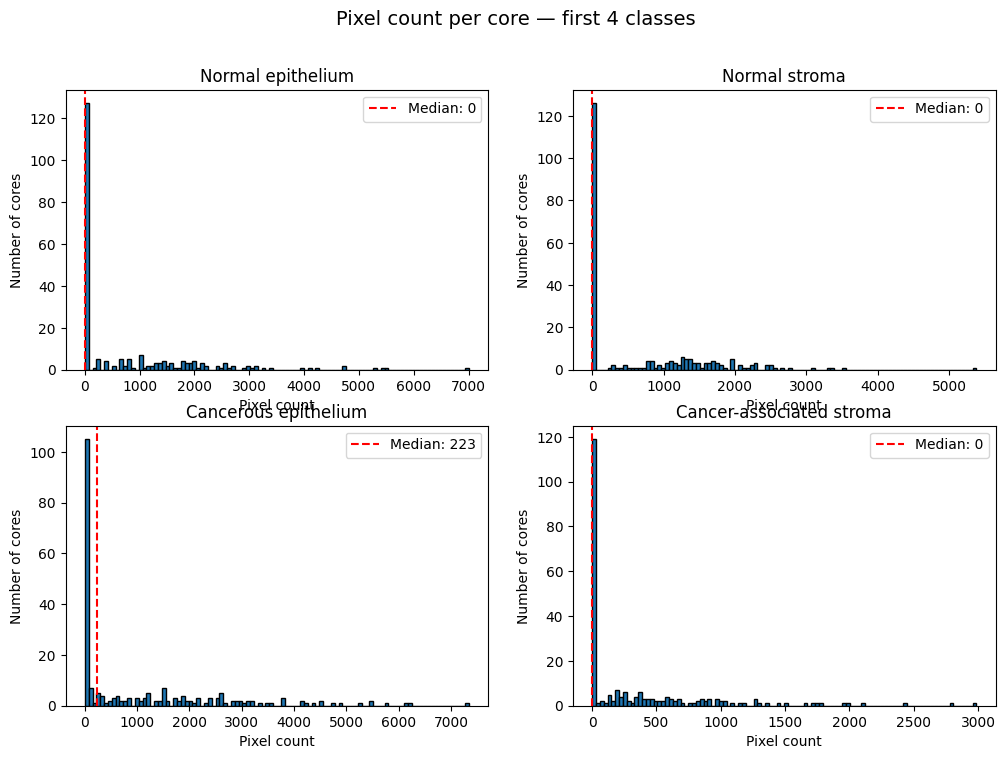

In [61]:
images_group = root["images"]
ALL_CLASSES = list(root.attrs["classes"])[:4]

data = {cls: [] for cls in ALL_CLASSES}

for name in sorted(images_group.keys()):
    y = images_group[name]["y"][:]
    for i, cls in enumerate(ALL_CLASSES):
        data[cls].append(int(np.sum(y == i)))

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Pixel count per core — first 4 classes", fontsize=14)

for ax, cls in zip(axes.flat, ALL_CLASSES):
    counts = data[cls]
    ax.hist(counts, bins=100, edgecolor="black")
    ax.set_title(cls)
    ax.set_xlabel("Pixel count")
    ax.set_ylabel("Number of cores")
    ax.axvline(np.median(counts), color="red", linestyle="--", label=f"Median: {np.median(counts):.0f}")
    ax.legend()


In [58]:
import zarr
import numpy as np

zarr_path = "/mnt/ssd3/eirik/ProcessedData/pcuk.zarr"

root = zarr.open(zarr_path, mode="r")
images_group = root["images"]
ALL_CLASSES = list(root.attrs["classes"])

print(f"{'Core':<40} " + " ".join(f"{c[:8]:>10}" for c in ALL_CLASSES))
print("-" * (40 + 11 * len(ALL_CLASSES)))

for name in sorted(images_group.keys()):
    y = images_group[name]["y"][:]
    counts = [int(np.sum(y == i)) for i in range(len(ALL_CLASSES))]
    print(f"{name:<40} " + " ".join(f"{c:>10,}" for c in counts))

Core                                       Normal e   Normal s   Cancerou   Cancer-a   Corpora       Blood   Crushed    Immune i   Necrotic
-------------------------------------------------------------------------------------------------------------------------------------------
s02_c005                                      2,103      1,389          0          0          0          0          0          0          0
s02_c010                                          0          0      2,857          0          0          0          0          0          0
s02_c012                                      1,974      1,781          0          0          0          0          0          0          0
s02_c014                                      1,347      2,255          0          0          0         14          0          0          0
s02_c016                                          0          0      5,484        711          0          0          0          0          0
s02_c023            

In [41]:
seed_list = list(range(1, 4))
spectra_per_class_list = [2**i for i in range(5, 13)]

result_dict = compile_results(store, augment_train=False, seeds=seed_list, spectra_per_class=spectra_per_class_list)
raw_sizes, raw_acc = get_accuracy(result_dict)

result_dict = compile_results(store, augment_train=True, seeds=seed_list, spectra_per_class=spectra_per_class_list)
aug_sizes, aug_acc = get_accuracy(result_dict)

# Performance vs Dataset Size

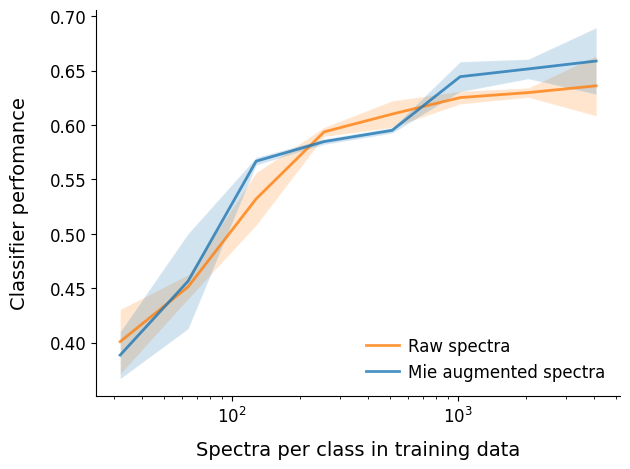

In [42]:
idx = np.argsort(raw_sizes)
plt.plot(np.array(raw_sizes)[idx], raw_acc[0, idx],  label='Raw spectra', 
            alpha=0.8, lw=2., color='tab:orange')
plt.fill_between(np.array(raw_sizes)[idx], raw_acc[0, idx] - raw_acc[1], raw_acc[0, idx] + raw_acc[1], raw_acc[0, idx],  
            alpha=0.2, color='tab:orange', edgecolor='white')

idx = np.argsort(aug_sizes)
plt.plot(np.array(aug_sizes)[idx], aug_acc[0, idx],  label='Mie augmented spectra', 
            alpha=0.8, lw=2., color='tab:blue')
plt.fill_between(np.array(aug_sizes)[idx], aug_acc[0, idx] - aug_acc[1], aug_acc[0, idx] + aug_acc[1], aug_acc[0, idx],  
            alpha=0.2, color='tab:blue', edgecolor='white')

plt.gca().set_xscale('log')
plt.xlabel('Spectra per class in training data', fontsize=14, labelpad=10)
plt.ylabel('Classifier perfomance', fontsize=14, labelpad=15)
plt.legend(handletextpad=0.5, frameon=0, fontsize=12, loc='lower right')

ax = plt.gca()
ax.tick_params(labelsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
# plt.savefig('raw_spectra_acc_v_spectra_per_class.svg', format='svg', bbox_inches='tight', dpi=300)

# Performance for different augmentations

In [8]:
acc_list_16 = []
std_list_16 = []

acc_list_16.append(raw_acc[:, np.array(raw_sizes) == 16][0,0])
std_list_16.append(raw_acc[:, np.array(raw_sizes) == 16][1,0])

acc_list_16.append(noise_acc[:, np.array(noise_sizes) == 16][0,0])
std_list_16.append(noise_acc[:, np.array(noise_sizes) == 16][1,0])

acc_list_16.append(aug_acc[:, np.array(aug_sizes) == 16][0,0])
std_list_16.append(aug_acc[:, np.array(aug_sizes) == 16][1,0])

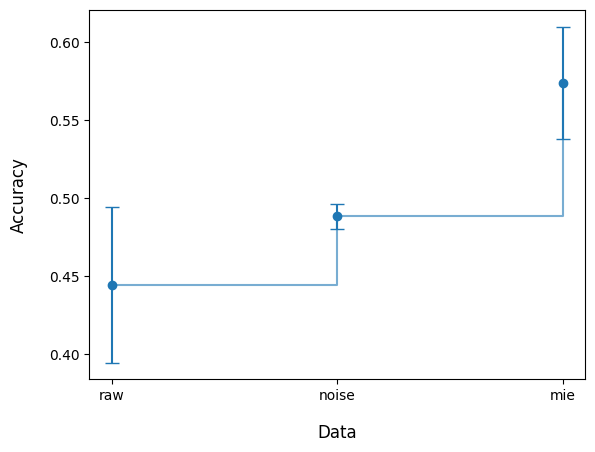

In [10]:
x_labels = ['raw', 'noise', 'mie'] 
x = range(len(acc_list_16))
plt.step(x, acc_list_16, where='post', label='Mean Accuracy', color='tab:blue', alpha=0.6)
plt.errorbar(x , acc_list_16, yerr=np.array(std_list_16), fmt='o', capsize=5)

plt.xticks(x, x_labels)

plt.xlabel('Data', fontsize=12, labelpad=15)
plt.ylabel('Accuracy', fontsize=12, labelpad=15)
plt.show()

# Confusion Matrix

In [ ]:
img_result = load_image_outputs(store, trial_id, image_name)
result_dict[128]['N128_seed00']

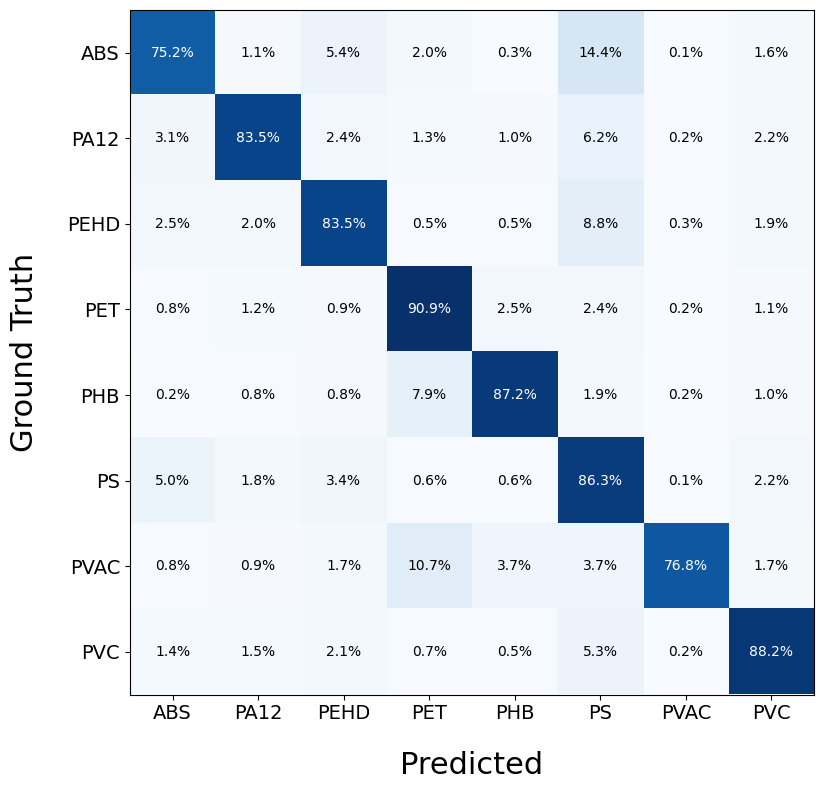

In [158]:
gt = result_dict[128]['N128_seed00']['gt']
pred = result_dict[128]['N128_seed00']['pred']  

cm = confusion_matrix(gt, pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

class_labels = ['ABS', 'PA12', 'PEHD', 'PET', 'PHB', 'PS', 'PVAC', 'PVC']       # MUST FIX THIS!

fig, ax = plt.subplots(figsize=(10, 8))
cax = ax.matshow(cm_normalized, cmap='Blues')

ax.set_xticks(np.arange(len(class_labels)))
ax.set_yticks(np.arange(len(class_labels)))
ax.set_xticklabels(class_labels, rotation=0, ha='center', fontsize=14)
ax.set_yticklabels(class_labels, fontsize=14)

ax.xaxis.set_ticks_position('bottom')
ax.xaxis.set_label_position('bottom')

for i in range(cm_normalized.shape[0]):
    for j in range(cm_normalized.shape[1]):
        ax.text(
            j, i,
            f"{cm_normalized[i, j]:.1f}%",
            ha='center',
            va='center',
            color='white' if cm_normalized[i, j] > 50 else 'black', 
            fontsize=10
        )
    
    
ax.set_xlabel('Predicted', fontsize=22, labelpad=20)
ax.set_ylabel('Ground Truth', fontsize=22, labelpad=20)
plt.tight_layout()
plt.show()